In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [10]:
from src.model import load_vitb16_model
model = load_vits16_model() # smallest

Loading EM and segmentation data...


/opt/homebrew/Caskroom/miniconda/base/envs/mito-mia/lib/python3.12/site-packages/fibsem_tools/io/n5/core.py:101: FutureWarning: The N5FSStore is deprecated and will be removed in a Zarr-Python version 3, see https://github.com/zarr-developers/zarr-python/issues/1274 and https://github.com/zarr-developers/n5py for more information.
  store = DEFAULT_N5_STORE(store, **kwargs.pop("storage_options", {}))


Generating slices...
Building mitochondria to slices catalog...
todo: Randomly selecting 10 slices for quick analysis
0/10 - 00:00:00.495
9/10 - 00:00:03.894
Computing embeddings for each slice....
0/10 - 00:00:01.158
Computing mitochondrial embeddings....
0/80 - 00:00:01.599
10/80 - 00:00:04.074
20/80 - 00:00:06.410
30/80 - 00:00:08.882
40/80 - 00:00:11.298
50/80 - 00:00:13.794
60/80 - 00:00:16.400
70/80 - 00:00:18.861
79/80 - 00:00:20.949
Running single dataset analysis....


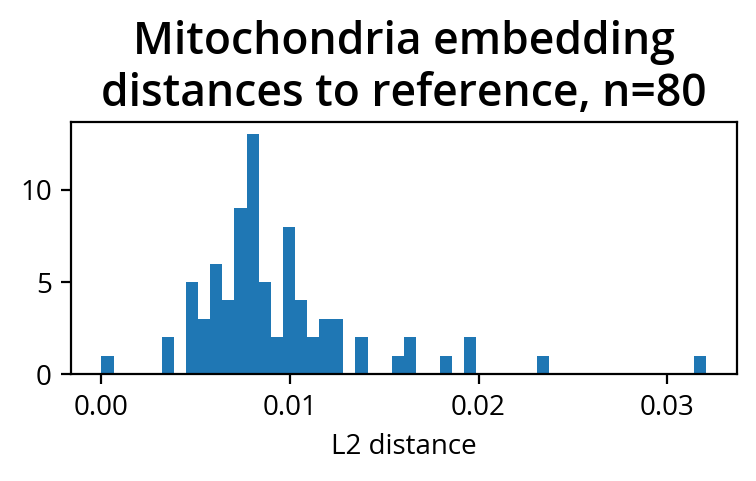

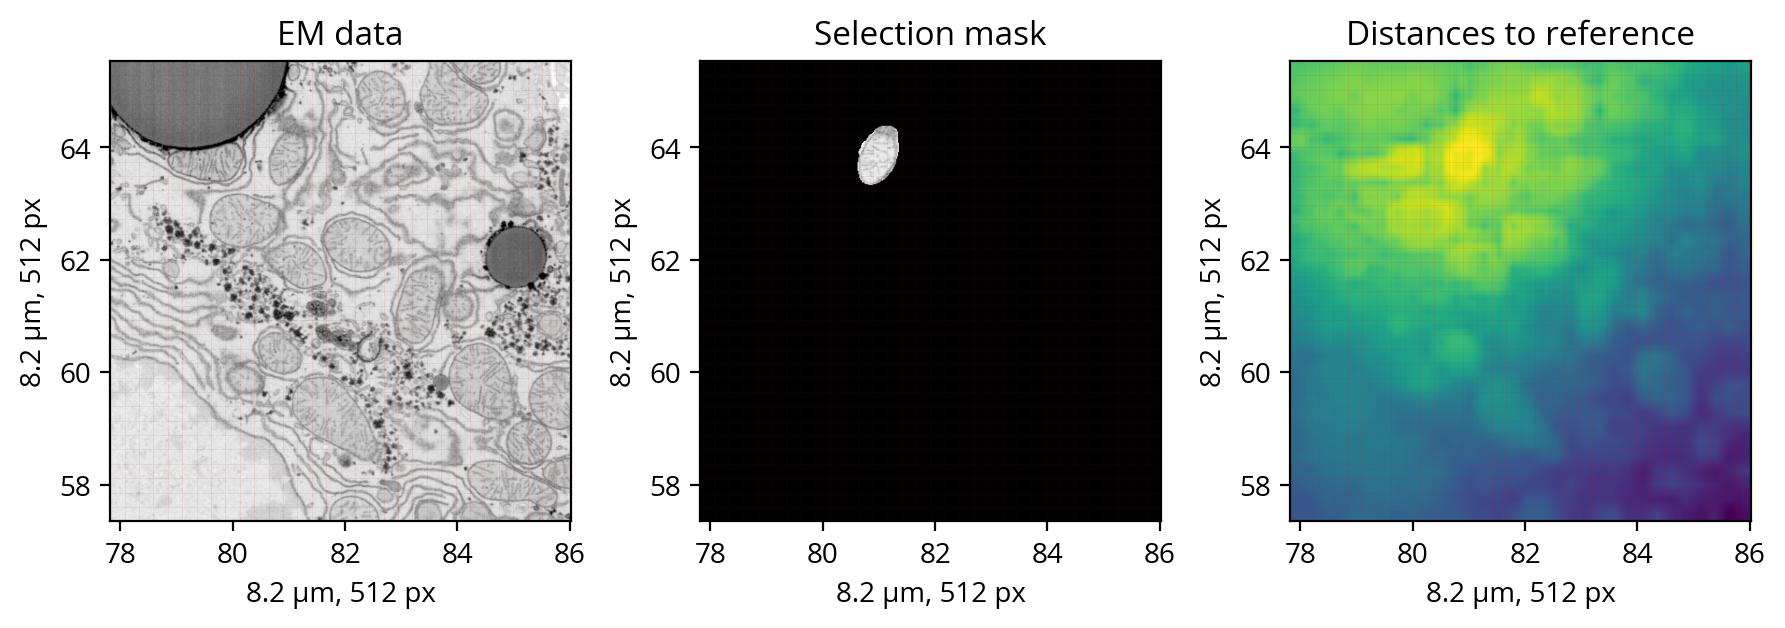

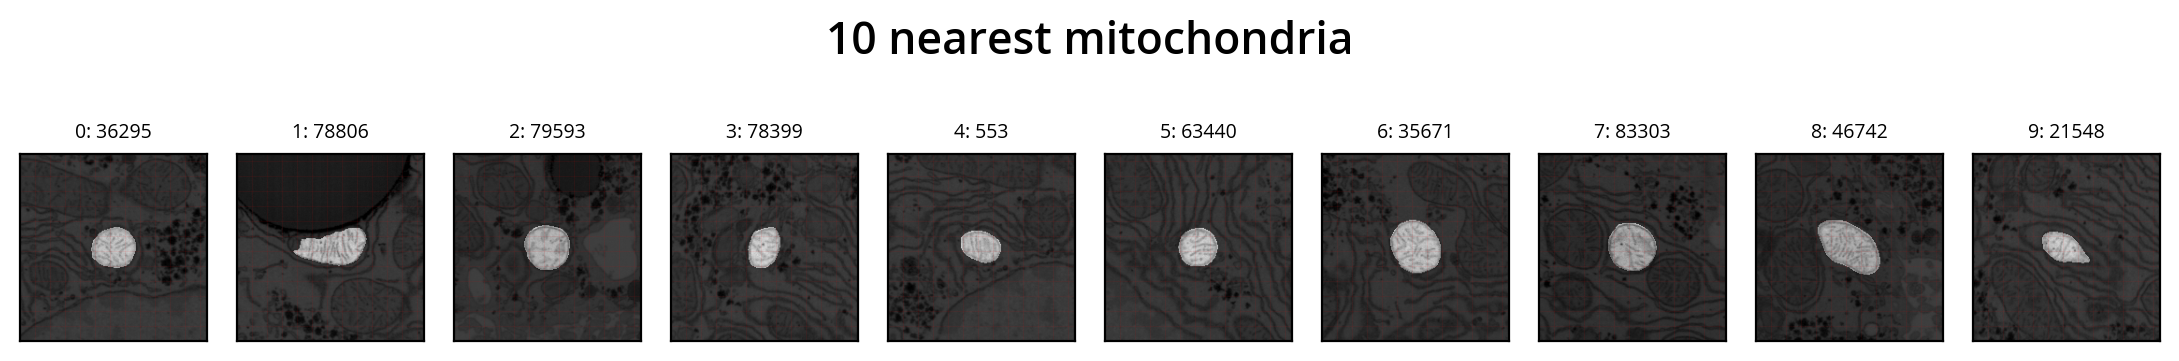

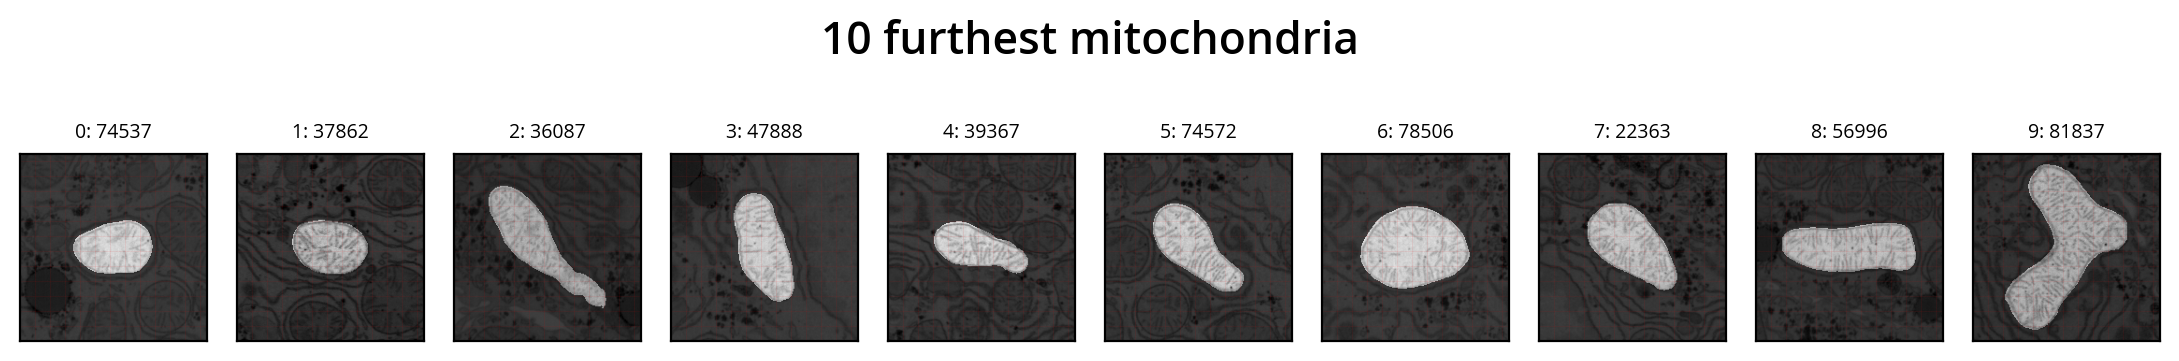

In [381]:
from src.dataset_pipeline import DatasetPipeline
from src.data_manager import DataManager

group_url = 's3://janelia-cosem-datasets/jrc_mus-liver/jrc_mus-liver.n5/em/fibsem-uint8/' 
seg_url = 's3://janelia-cosem-datasets/jrc_mus-liver/jrc_mus-liver.n5/labels/mito_seg/'
pipeline_mus_liver = DatasetPipeline(group_url, seg_url, 's1', 's0', model, name='mus-liver')                                                       
pipeline_mus_liver.run()

Loading EM and segmentation data...
Computing mitochondrial embeddings....
0/98 - 00:00:01.952
10/98 - 00:00:03.048
20/98 - 00:00:04.097
30/98 - 00:00:07.702
40/98 - 00:00:08.634
50/98 - 00:00:11.304
60/98 - 00:00:12.338
70/98 - 00:00:16.388
80/98 - 00:00:18.878
90/98 - 00:00:21.268
97/98 - 00:00:25.883
Running single dataset analysis....


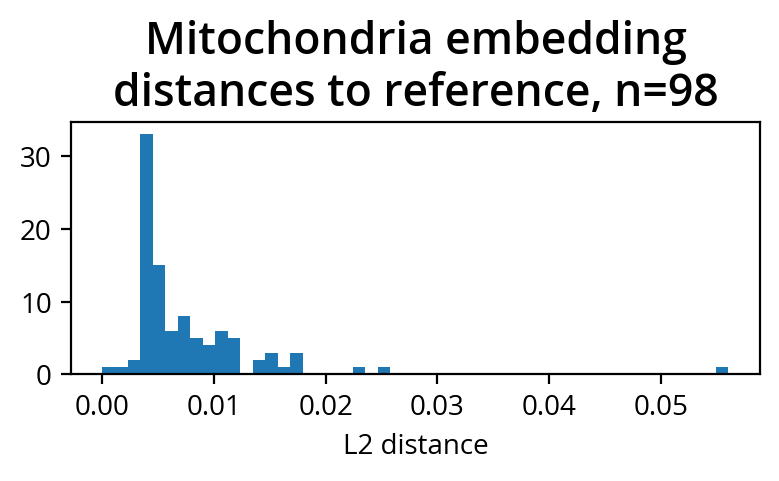

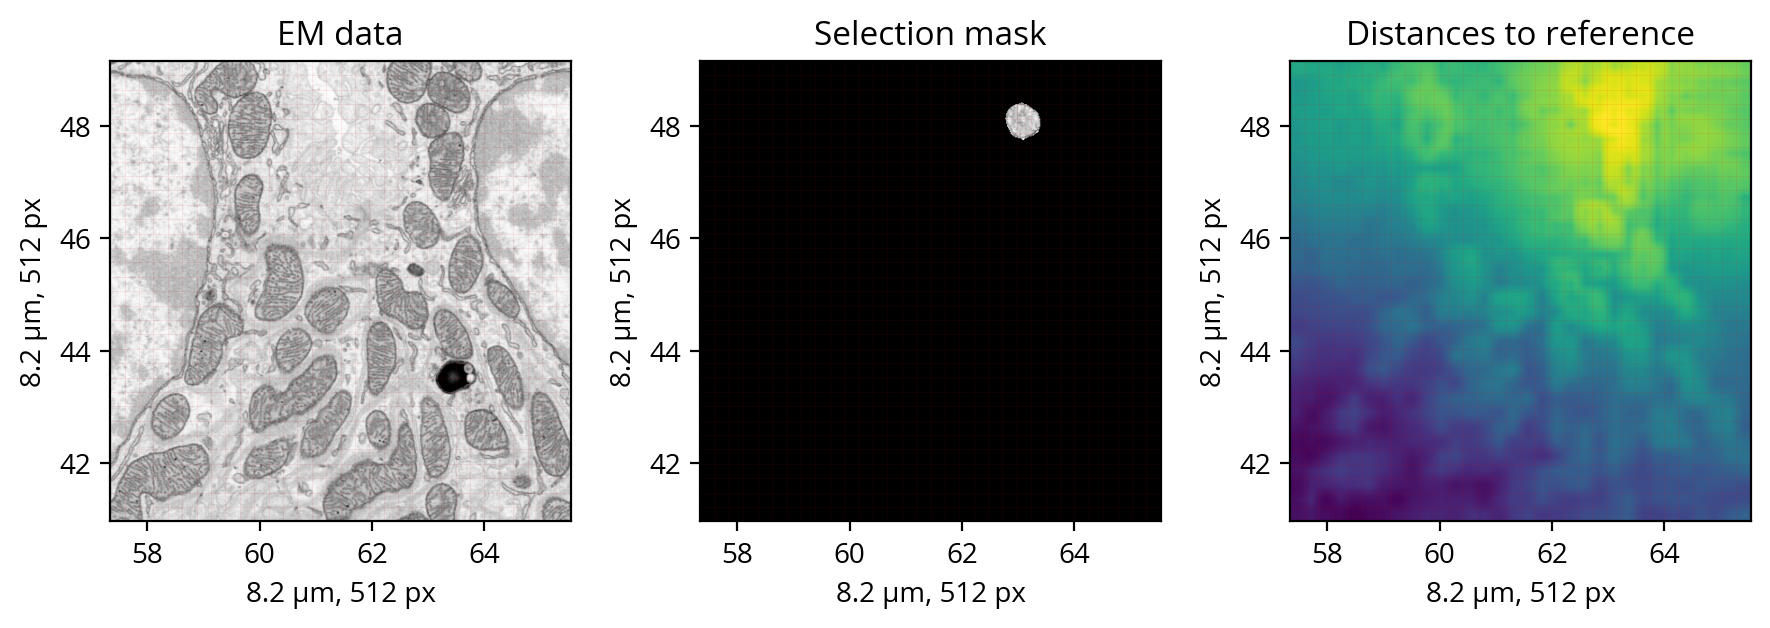

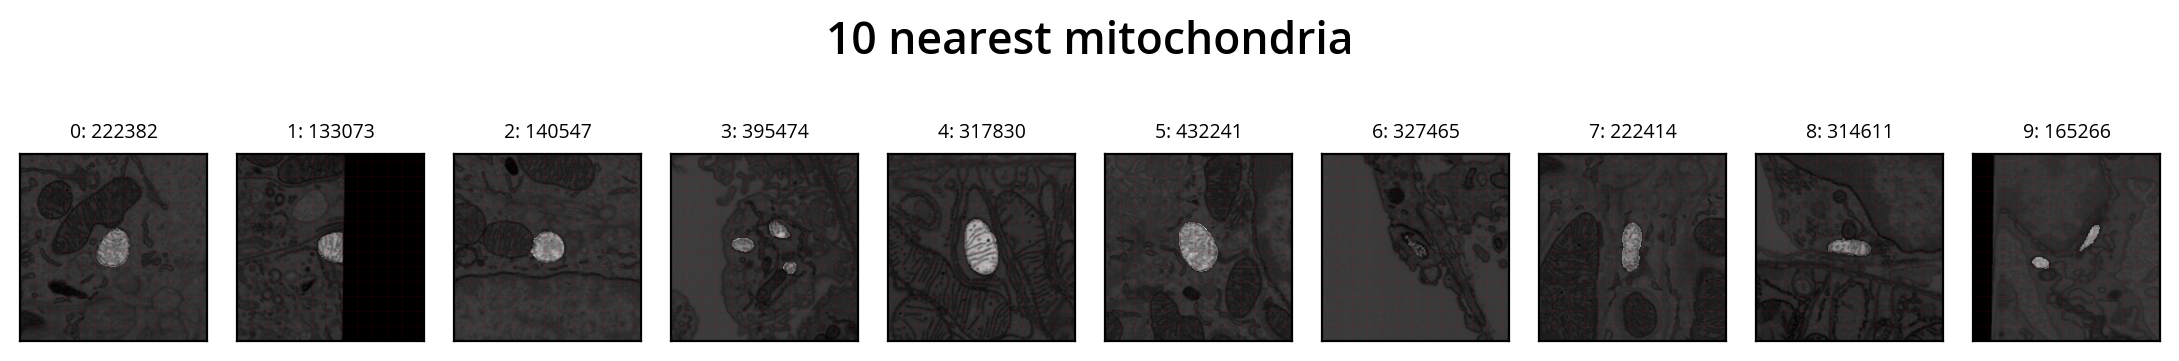

Slice Slice at (z:slice(10995, 10995, None), y:slice(2574, 2819, None), x:slice(3936, 3998, None)), exceeds padding size parameter, reverting to plot entire slice.
Slice Slice at (z:slice(8174, 8174, None), y:slice(3385, 3594, None), x:slice(464, 545, None)), exceeds padding size parameter, reverting to plot entire slice.
Slice Slice at (z:slice(5967, 5967, None), y:slice(1204, 1495, None), x:slice(1697, 1810, None)), exceeds padding size parameter, reverting to plot entire slice.


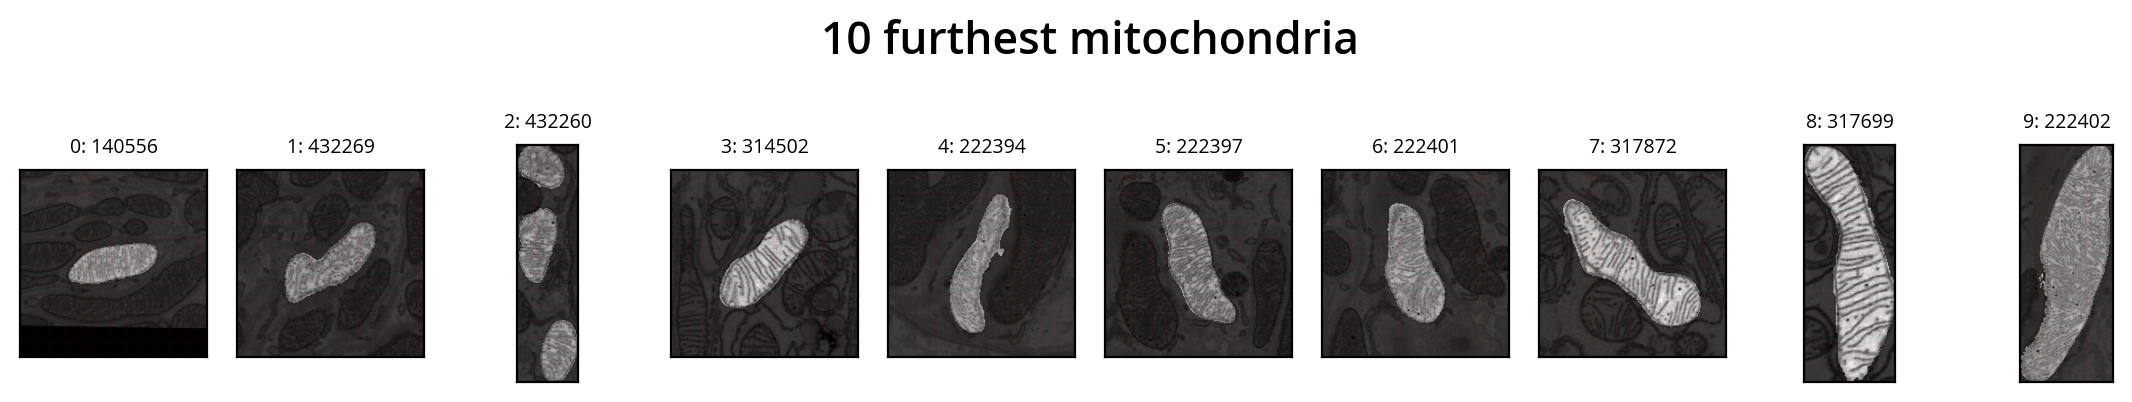

In [386]:
group_url = 's3://janelia-cosem-datasets/jrc_mus-kidney/jrc_mus-kidney.n5/em/fibsem-uint8/' 
seg_url = 's3://janelia-cosem-datasets/jrc_mus-kidney/jrc_mus-kidney.n5/labels/empanada-mito_seg/'
pipeline_mus_kidney = DatasetPipeline(group_url, seg_url, 's1', 's0', model, name='mus-kidney')                                                       
pipeline_mus_kidney.run()


In [393]:
_ = pipeline_mus_kidney.compute_embeddings()

0/10 - 00:00:01.491


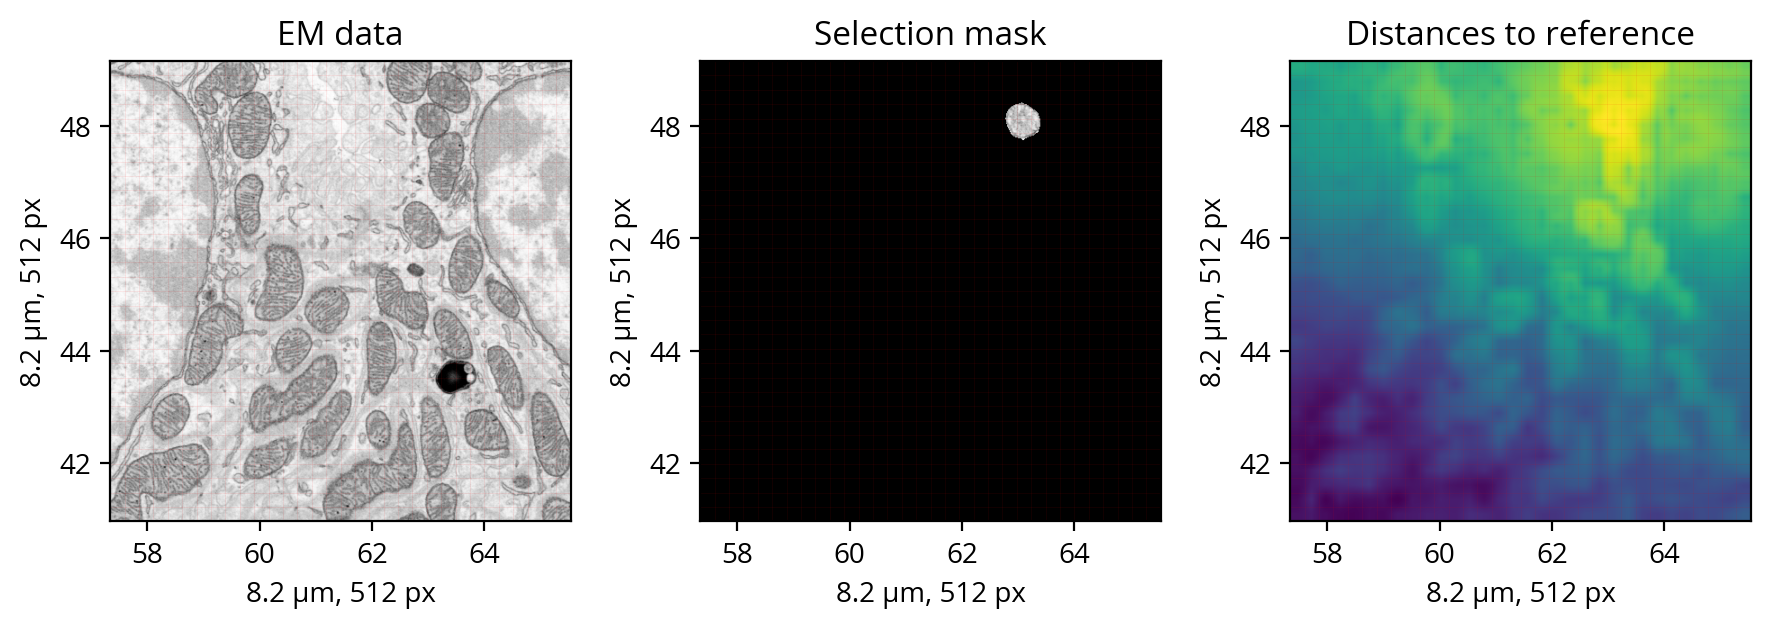

In [394]:
ref_analyzer = pipeline_mus_kidney.reference_analyzer

ref_analyzer.set_reference(ref_analyzer.pipeline.mito_ids()[2])
ref_analyzer.compute_distances()
ref_analyzer.plot_reference()
